#CONNECT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# LSTM MODEL

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
def create_lstm_tensors(file_path, station_name): # create tensors
    print(f"\nProcessing: {station_name}")

    save_dir = "/content/tensors"
    os.makedirs(save_dir, exist_ok=True)

    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df = df.dropna()
    wind_idx = list(df.columns).index('wind_speed')

    X_df = df.copy()
    y_df = df[['wind_speed']].copy()

    n = len(df)
    train_end = int(n * 0.7)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(X_df.iloc[:train_end])
    scaler_y.fit(y_df.iloc[:train_end])

    X_scaled = scaler_X.transform(X_df)
    y_scaled = scaler_y.transform(y_df)

    seq_len = 24
    X_list, y_list = [], []

    for i in range(len(X_scaled) - seq_len - 8):
        X_list.append(X_scaled[i:i+seq_len])
        y_list.append([
            y_scaled[i+seq_len+1][0],
            y_scaled[i+seq_len+3][0],
            y_scaled[i+seq_len+7][0]
        ])

    X_np = np.array(X_list)
    y_np = np.array(y_list)

    n_windows = len(X_np)
    w_train = int(n_windows * 0.7)
    w_val = int(n_windows * 0.85)

    X_train, y_train = X_np[:w_train], y_np[:w_train]
    X_val, y_val = X_np[w_train:w_val], y_np[w_train:w_val]
    X_test, y_test = X_np[w_val:], y_np[w_val:]

    tensors = (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32)
    )

    torch.save({
        "tensors": tensors,
        "wind_idx": wind_idx
    }, f"{save_dir}/{station_name}_tensors.pt")

    torch.save(scaler_y, f"{save_dir}/{station_name}_scaler.pt")

    print("Saved tensors + scaler")

class LSTMModel(nn.Module): # model
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


def train_lstm(station_name):
    print(f"Xử lý trạm: {station_name}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Đang chạy trên thiết bị: {device}")

    tensor_path = f"/content/tensors/{station_name}_tensors.pt"
    scaler_path = f"/content/tensors/{station_name}_scaler.pt"

    data = torch.load(tensor_path, weights_only=False)
    X_train, y_train, X_val, y_val, X_test, y_test = data["tensors"]
    wind_idx = data["wind_idx"]
    scaler = torch.load(scaler_path, weights_only=False)

    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val     = X_val.to(device), y_val.to(device)
    X_test, y_test   = X_test.to(device), y_test.to(device)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

    model = LSTMModel(X_train.shape[2]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_loss = float('inf')
    patience = 10
    counter = 0

    epoch_times = []
    total_train_start = time.time()

    train_losses = []
    val_losses = []

    print("\nBắt đầu quá trình huấn luyện...")

    for epoch in range(50):
        epoch_start = time.time()
        model.train()
        epoch_loss = 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb_v, yb_v in val_loader:
                val_pred = model(Xb_v)
                val_loss += criterion(val_pred, yb_v).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        train_losses.append(train_loss) # Lưu trữ Loss mỗi epoch
        val_losses.append(val_loss)

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f"/content/{station_name}_best_lstm.pt")
            best_epoch_msg = f" (New Best)"
        else:
            counter += 1
            best_epoch_msg = ""

        if (epoch + 1) % 5 == 0 or best_epoch_msg != "":
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | Time: {epoch_time:.2f}s{best_epoch_msg}")

        if counter >= patience:
            print(f"Early stopping kích hoạt tại Epoch {epoch+1}!")
            break

    total_train_time = time.time() - total_train_start
    avg_epoch_time = np.mean(epoch_times)

    print("\nSố liệu chi phí tài nguyên (bảng 6 và 7)")
    print(f"Tổng thời gian huấn luyện (Total training time) : {total_train_time:.2f} s")
    print(f"Thời gian trung bình 1 epoch (Time/epoch)       : {avg_epoch_time:.2f} s")

    model.load_state_dict(torch.load(f"/content/{station_name}_best_lstm.pt"))
    model.cpu()
    model.eval()

    sample_input_cpu = X_test[0:1].cpu()

    with torch.no_grad():
        for _ in range(10):
            _ = model(sample_input_cpu)

    latencies = []
    with torch.no_grad():
        for _ in range(100):
            start_infer = time.time()
            _ = model(sample_input_cpu)
            latencies.append((time.time() - start_infer) * 1000)

    avg_latency = np.mean(latencies)
    print(f"Độ trễ suy luận trên CPU (Inference Latency)  : {avg_latency:.4f} ms/mẫu")

    model.to(device)
    model.eval()
    with torch.no_grad():
        y_pred_list = []
        test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)
        for Xb_t, _ in test_loader:
            y_pred_list.append(model(Xb_t).cpu().numpy())

        y_pred_scaled = np.vstack(y_pred_list)
        y_true_scaled = y_test.cpu().numpy()

        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_true_scaled)

    print("\nResult test")
    horizons = ["30min", "60min", "120min"]
    for i, h in enumerate(horizons):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        print(f"Horizon {h:6s}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | R2 = {r2:.4f}")

    overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\nGlobal RMSE: {overall_rmse:.4f}")

    # Biểu đồ
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=1.5)
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=1.5)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title(f"Loss Curve (LSTM) - {station_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    plot_steps = 200
    horizons_labels = ["30 Phút", "60 Phút", "120 Phút"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"LSTM Forecast vs Actual - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].plot(y_true[:plot_steps, i], label="Thực tế (Actual)", color='black', linewidth=1.5)
        axes[i].plot(y_pred[:plot_steps, i], label="Dự báo (Predicted)", color='red', linestyle='--', linewidth=1.5)
        axes[i].set_ylabel("Wind Speed (m/s)")
        axes[i].set_title(f"Horizon: {horizons_labels[i]}")
        axes[i].legend(loc="upper right")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    axes[2].set_xlabel("Time Steps (15-min intervals)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"LSTM Regression Fit - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].scatter(y_true[:, i], y_pred[:, i], alpha=0.3, color='royalblue', s=10)
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

        axes[i].set_title(f"{horizons_labels[i]} (R2: {r2_score(y_true[:, i], y_pred[:, i]):.3f})")
        axes[i].set_xlabel("Actual Wind Speed (m/s)")
        if i == 0: axes[i].set_ylabel("Predicted Wind Speed (m/s)")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

run


Processing: Tram_A_DatLien
Saved tensors + scaler

Processing: Tram_B_VenBien
Saved tensors + scaler

Processing: Tram_C_DoiNui
Saved tensors + scaler

Processing: Tram_D_NgoaiKhoi
Saved tensors + scaler
Xử lý trạm: Tram_A_DatLien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00203 | Val Loss: 0.00066 | Time: 4.23s (New Best)
Epoch 02 | Train Loss: 0.00067 | Val Loss: 0.00062 | Time: 4.87s (New Best)
Epoch 03 | Train Loss: 0.00060 | Val Loss: 0.00056 | Time: 4.70s (New Best)
Epoch 05 | Train Loss: 0.00054 | Val Loss: 0.00062 | Time: 4.85s
Epoch 07 | Train Loss: 0.00051 | Val Loss: 0.00053 | Time: 4.20s (New Best)
Epoch 10 | Train Loss: 0.00048 | Val Loss: 0.00055 | Time: 4.21s
Epoch 12 | Train Loss: 0.00045 | Val Loss: 0.00050 | Time: 4.87s (New Best)
Epoch 15 | Train Loss: 0.00044 | Val Loss: 0.00052 | Time: 4.69s
Epoch 20 | Train Loss: 0.00041 | Val Loss: 0.00051 | Time: 4.49s
Early stopping kích hoạt tại Epoch 22!

Số liệu chi phí tài nguyê

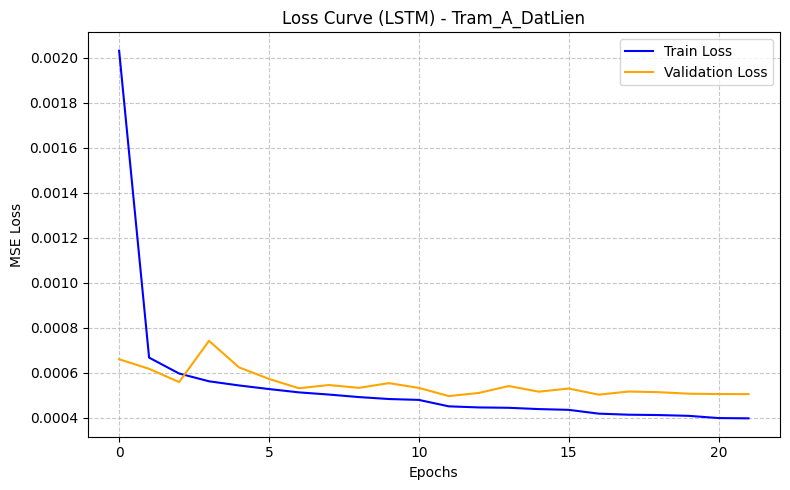

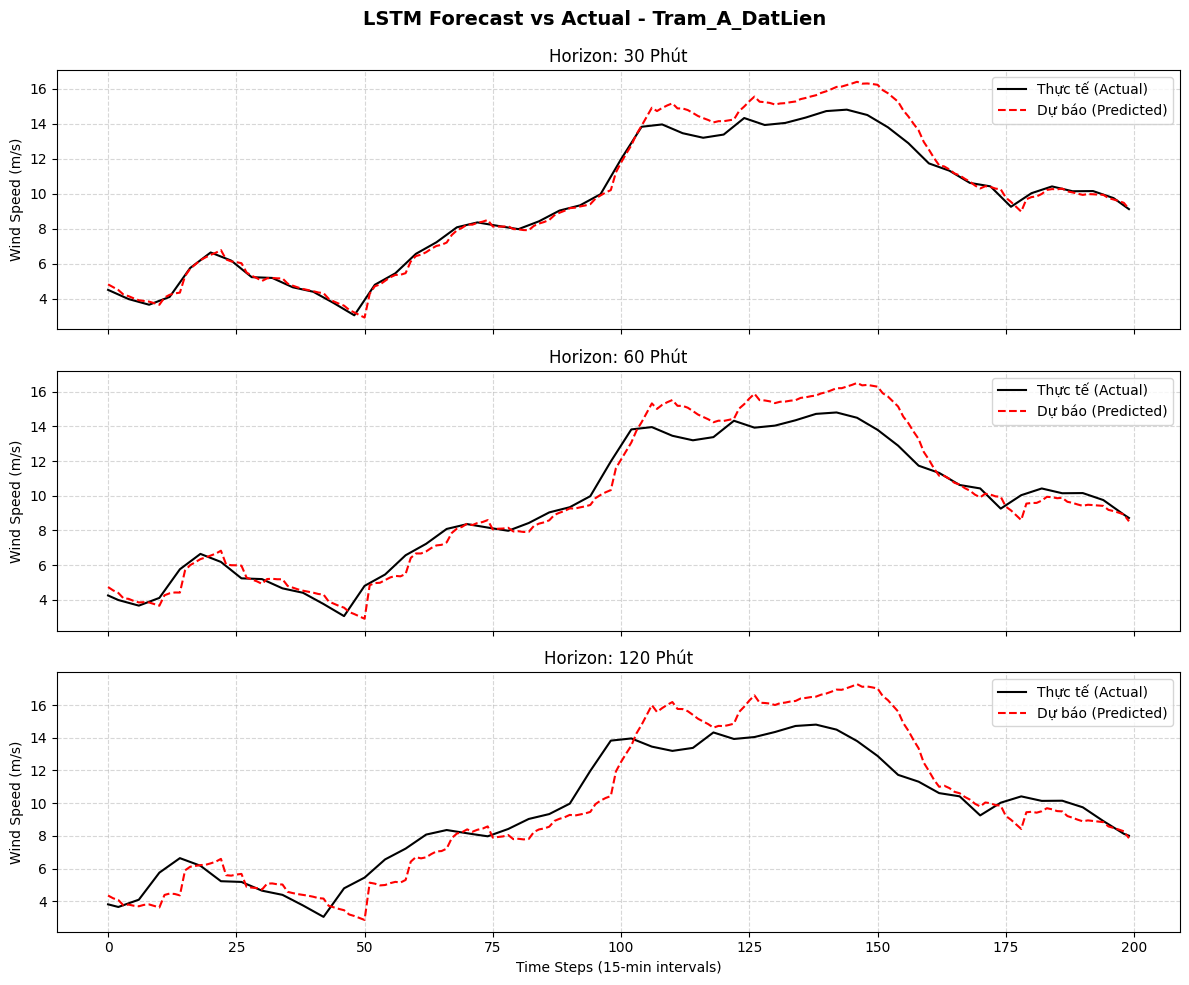

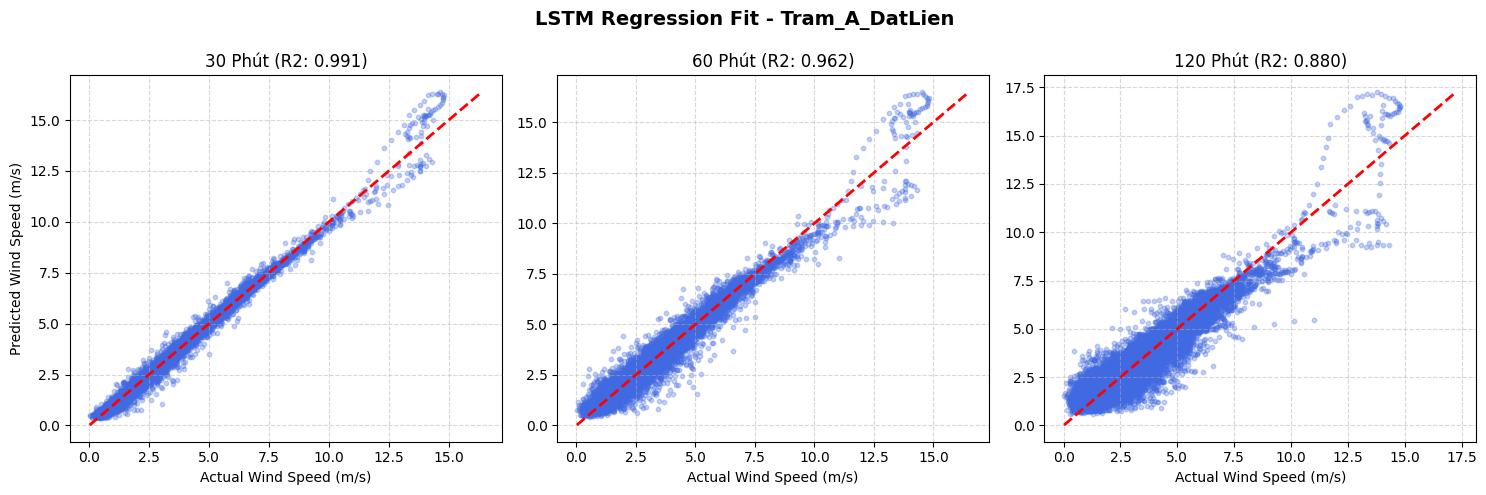

[-] Đã dọn dẹp bộ nhớ GPU sau khi hoàn thành Tram_A_DatLien

Xử lý trạm: Tram_B_VenBien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00403 | Val Loss: 0.00067 | Time: 5.12s (New Best)
Epoch 02 | Train Loss: 0.00079 | Val Loss: 0.00057 | Time: 4.26s (New Best)
Epoch 05 | Train Loss: 0.00062 | Val Loss: 0.00050 | Time: 4.34s (New Best)
Epoch 09 | Train Loss: 0.00056 | Val Loss: 0.00048 | Time: 4.12s (New Best)
Epoch 10 | Train Loss: 0.00055 | Val Loss: 0.00049 | Time: 4.81s
Epoch 11 | Train Loss: 0.00054 | Val Loss: 0.00047 | Time: 4.55s (New Best)
Epoch 14 | Train Loss: 0.00052 | Val Loss: 0.00046 | Time: 4.66s (New Best)
Epoch 15 | Train Loss: 0.00052 | Val Loss: 0.00051 | Time: 4.16s
Epoch 19 | Train Loss: 0.00047 | Val Loss: 0.00044 | Time: 4.58s (New Best)
Epoch 20 | Train Loss: 0.00046 | Val Loss: 0.00046 | Time: 4.91s
Epoch 24 | Train Loss: 0.00043 | Val Loss: 0.00044 | Time: 4.14s (New Best)
Epoch 25 | Train Loss: 0.00043 | Val Loss: 0.0

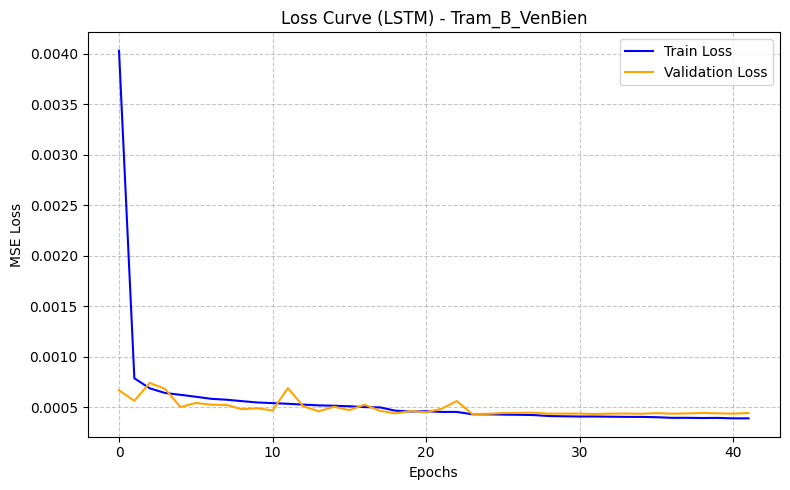

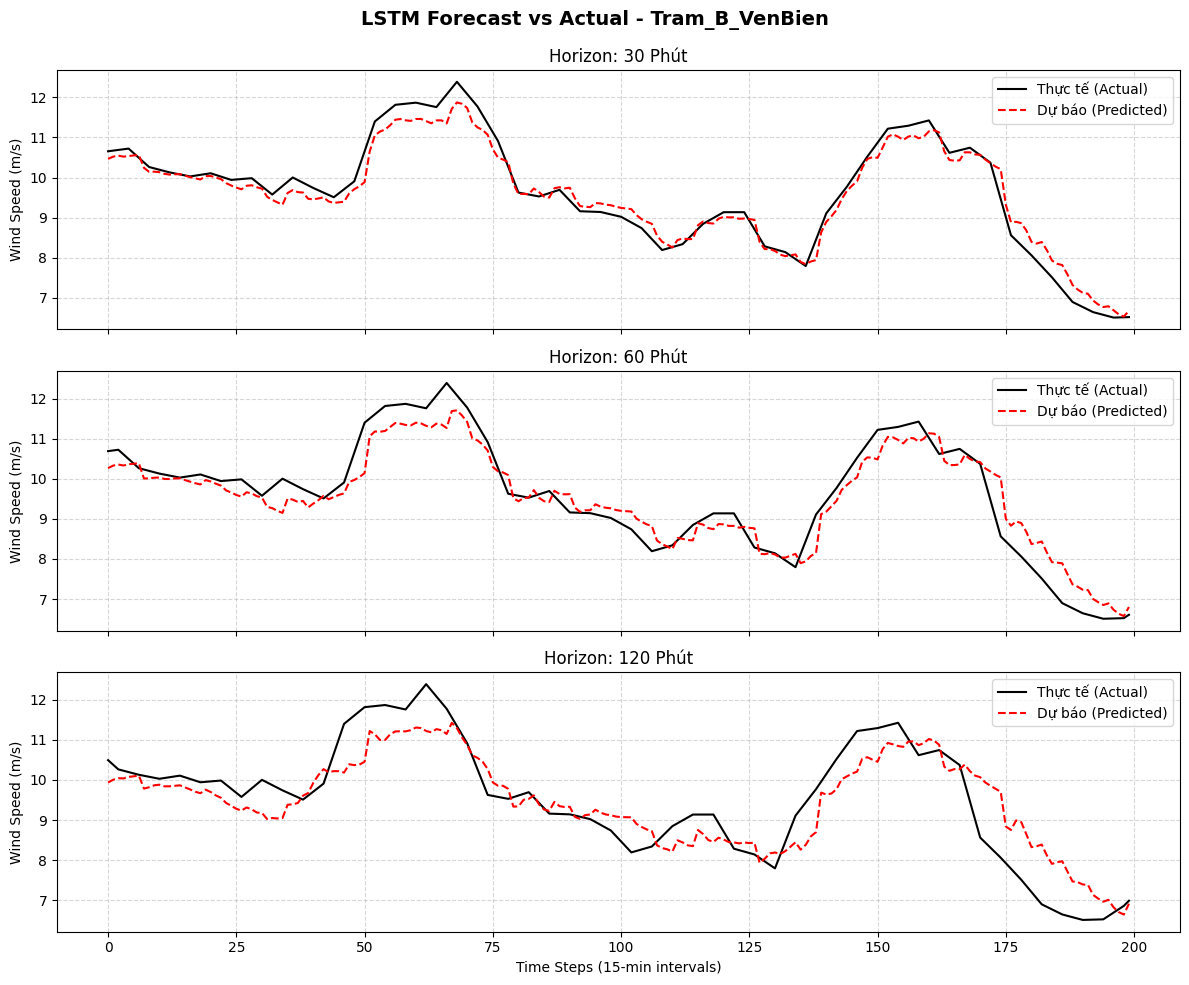

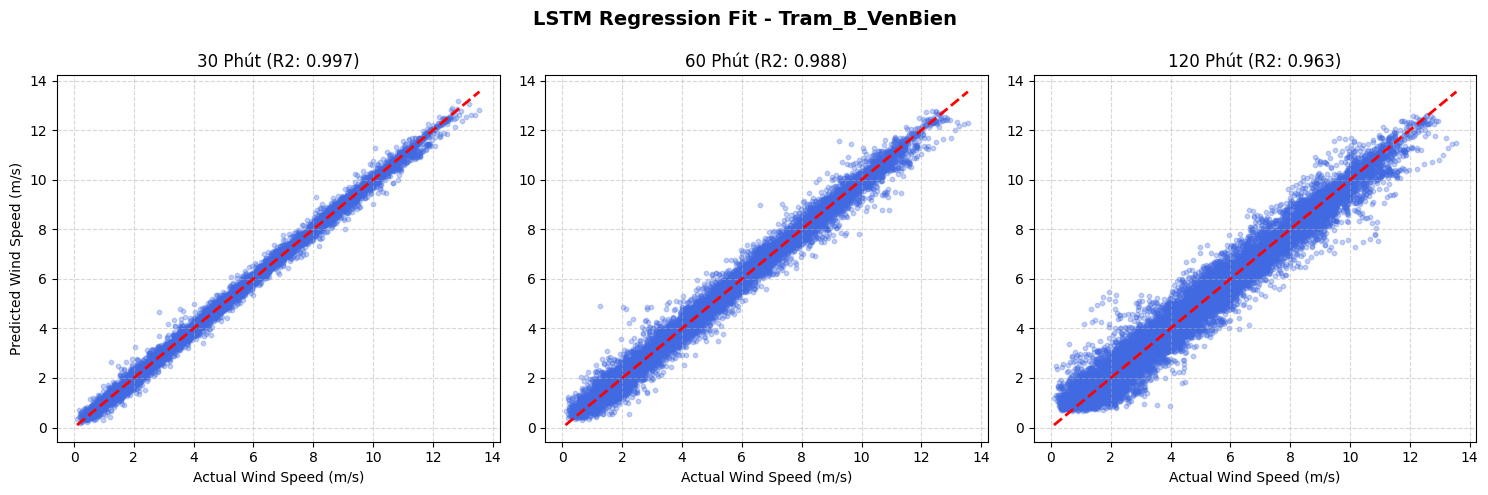

[-] Đã dọn dẹp bộ nhớ GPU sau khi hoàn thành Tram_B_VenBien

Xử lý trạm: Tram_C_DoiNui
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00329 | Val Loss: 0.00127 | Time: 4.66s (New Best)
Epoch 02 | Train Loss: 0.00124 | Val Loss: 0.00109 | Time: 4.75s (New Best)
Epoch 04 | Train Loss: 0.00104 | Val Loss: 0.00105 | Time: 4.50s (New Best)
Epoch 05 | Train Loss: 0.00102 | Val Loss: 0.00096 | Time: 4.84s (New Best)
Epoch 06 | Train Loss: 0.00097 | Val Loss: 0.00089 | Time: 4.15s (New Best)
Epoch 10 | Train Loss: 0.00091 | Val Loss: 0.00097 | Time: 4.33s
Epoch 11 | Train Loss: 0.00084 | Val Loss: 0.00088 | Time: 4.99s (New Best)
Epoch 13 | Train Loss: 0.00083 | Val Loss: 0.00087 | Time: 4.19s (New Best)
Epoch 15 | Train Loss: 0.00081 | Val Loss: 0.00090 | Time: 4.15s
Epoch 16 | Train Loss: 0.00080 | Val Loss: 0.00085 | Time: 4.16s (New Best)
Epoch 20 | Train Loss: 0.00077 | Val Loss: 0.00090 | Time: 5.28s
Epoch 25 | Train Loss: 0.00070 | Val Loss: 0.00

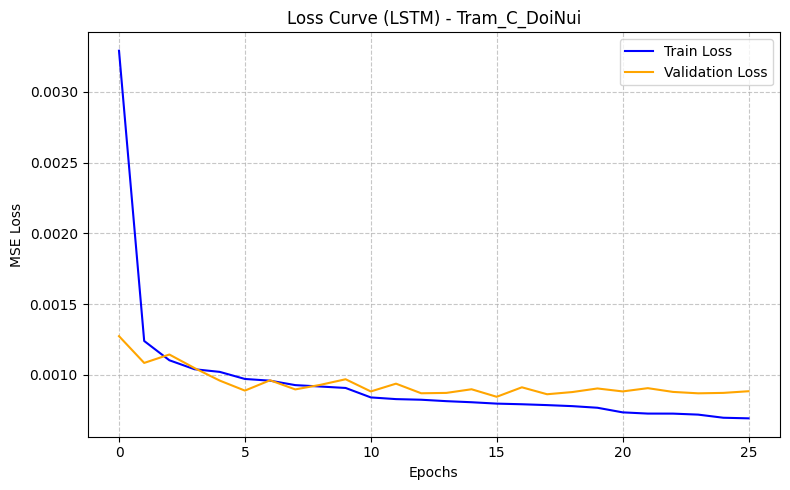

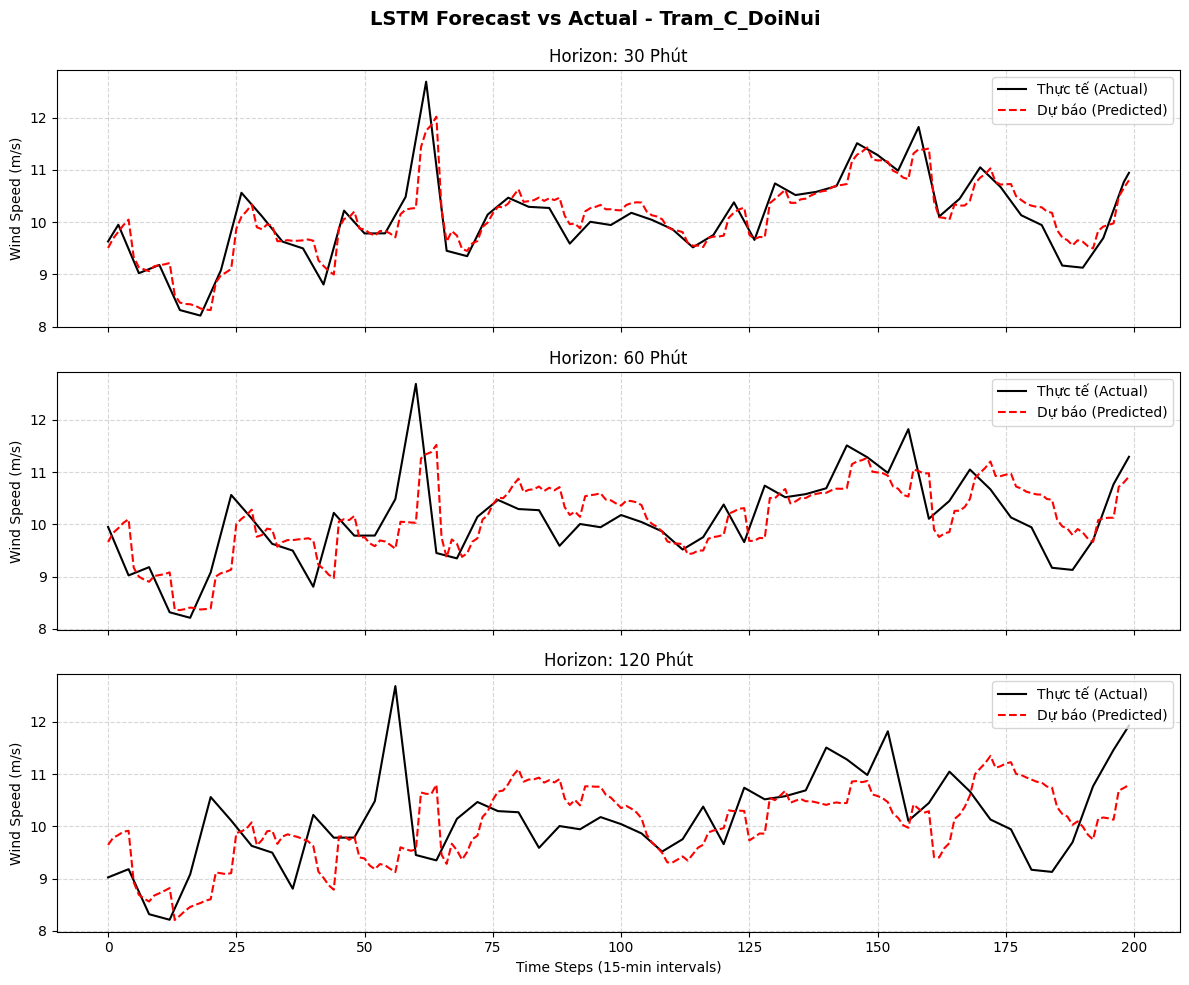

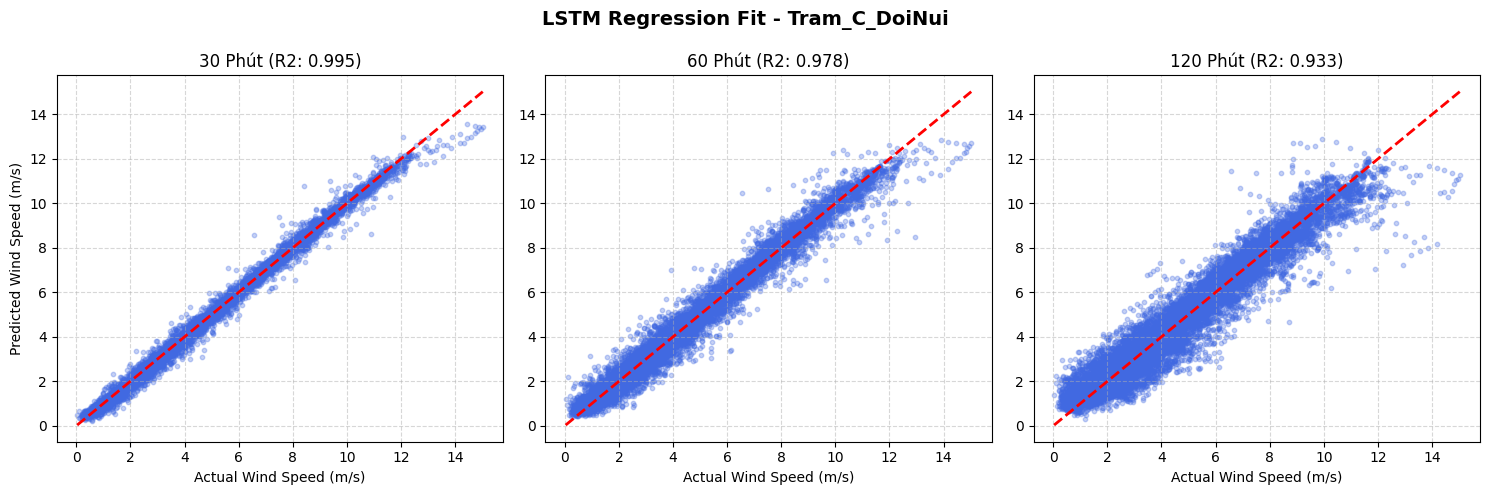

[-] Đã dọn dẹp bộ nhớ GPU sau khi hoàn thành Tram_C_DoiNui

Xử lý trạm: Tram_D_NgoaiKhoi
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00195 | Val Loss: 0.00071 | Time: 4.15s (New Best)
Epoch 02 | Train Loss: 0.00043 | Val Loss: 0.00034 | Time: 4.57s (New Best)
Epoch 04 | Train Loss: 0.00033 | Val Loss: 0.00031 | Time: 4.08s (New Best)
Epoch 05 | Train Loss: 0.00032 | Val Loss: 0.00030 | Time: 4.52s (New Best)
Epoch 10 | Train Loss: 0.00026 | Val Loss: 0.00029 | Time: 4.10s (New Best)
Epoch 12 | Train Loss: 0.00026 | Val Loss: 0.00027 | Time: 5.12s (New Best)
Epoch 15 | Train Loss: 0.00025 | Val Loss: 0.00026 | Time: 5.23s (New Best)
Epoch 16 | Train Loss: 0.00024 | Val Loss: 0.00026 | Time: 4.17s (New Best)
Epoch 20 | Train Loss: 0.00023 | Val Loss: 0.00027 | Time: 4.17s
Epoch 22 | Train Loss: 0.00022 | Val Loss: 0.00026 | Time: 4.16s (New Best)
Epoch 25 | Train Loss: 0.00021 | Val Loss: 0.00027 | Time: 4.16s
Epoch 26 | Train Loss: 0.00021 | V

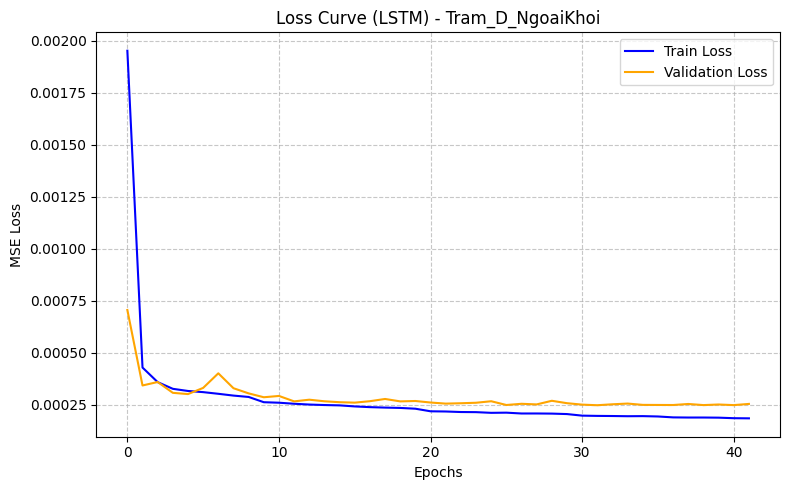

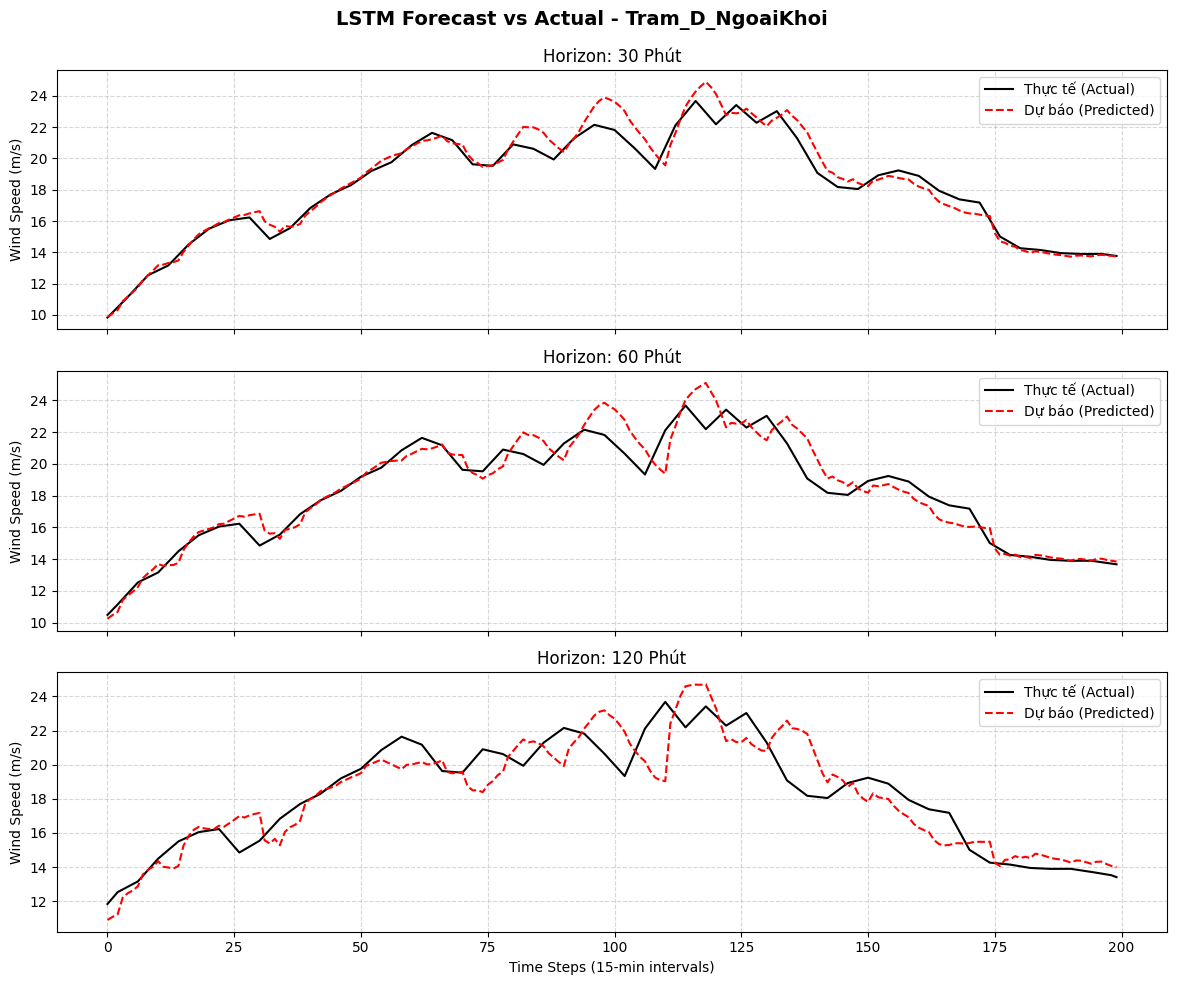

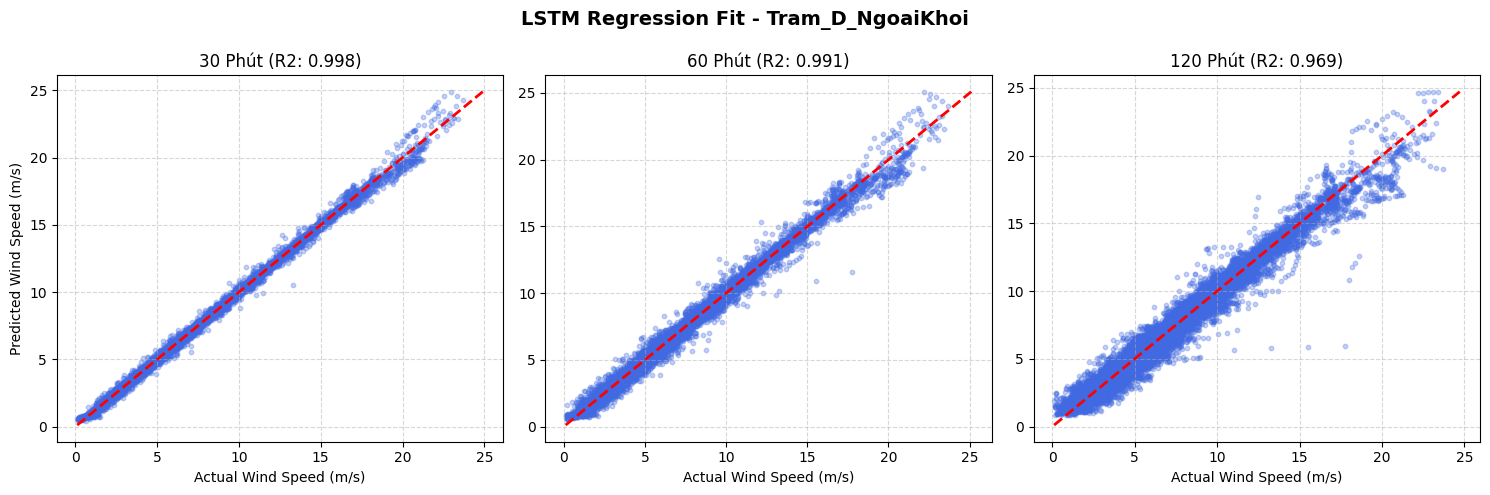

[-] Đã dọn dẹp bộ nhớ GPU sau khi hoàn thành Tram_D_NgoaiKhoi


Hoàn thành pipeline!
Tổng thời gian chạy: 10.26 phút


In [ ]:
import torch
import gc

stations = [
    "Tram_A_DatLien",
    "Tram_B_VenBien",
    "Tram_C_DoiNui",
    "Tram_D_NgoaiKhoi"
]

base_path = '/content/drive/MyDrive/WIND_FORECAST_DATA/'

start_all = time.time()

for station in stations:
    path = f"{base_path}{station}_FINAL_MASTER.csv"
    create_lstm_tensors(path, station)

for station in stations:
    train_lstm(station)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"[-] Đã dọn dẹp bộ nhớ GPU sau khi hoàn thành {station}\n")

total_time = time.time() - start_all

print(f"\nHoàn thành pipeline!")
print(f"Tổng thời gian chạy: {total_time/60:.2f} phút")